# COMP 5630/6630 — Assignment 2: Logistic Regression and Feature Analysis

**Author:** Trisha Balamurugan  
**Date:** Spring 2026  

## Overview

This notebook implements and evaluates binary logistic regression classifiers on the Iris dataset using the One-vs-Rest (OvR) approach.  

- Part 1: Data loading, preprocessing, and binary target creation  
- Part 2: Logistic regression from scratch with gradient ascent  
- Part 3: Scikit-learn OvR logistic regression (no regularization)  
- Part 4: L1-regularized logistic regression using scikit-learn  
- Part 5: Model evaluation and comparison  
- Part 6: Analysis and reflection  
- Bonus: L1-regularized logistic regression from scratch using subgradient method  

The notebook explores **feature importance, model sparsity, and interpretability** of logistic regression for multi-class classification.


**GenAI Usage Declaration:
ChatGPT was used for guidance, debugging, and code structuring.**


# **Part 1 — Dataset and Preprocessing**

Step 1–4: Load and preprocess data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter


Load DataSet

In [28]:
iris = load_iris()

X = iris.data
y = iris.target

print("Shape of X:", X.shape)
print("Class distribution:", Counter(y))


Shape of X: (150, 4)
Class distribution: Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})


Train-Test spilt

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=15
)

Standardize Features

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Create binary targets (OvR)

In [6]:
def make_binary(y, c):
    return (y == c).astype(int)

y_train_0 = make_binary(y_train, 0)
y_train_1 = make_binary(y_train, 1)
y_train_2 = make_binary(y_train, 2)


# **Part 2 — Logistic Regression from Scratch**

Sigmoid function

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


Log-likelihood and gradient

In [8]:
def log_likelihood(X, y, w):
    z = X @ w
    y_hat = sigmoid(z)

    eps = 1e-9
    return np.sum(y * np.log(y_hat + eps) +
                  (1 - y) * np.log(1 - y_hat + eps))


Gradient ascent

In [9]:
def train_logistic(X, y, lr=0.0001, iterations=8000):
    n, d = X.shape

    X_bias = np.c_[np.ones(n), X]
    w = np.zeros(d + 1)

    losses = []

    for _ in range(iterations):
        z = X_bias @ w
        y_hat = sigmoid(z)

        gradient = X_bias.T @ (y - y_hat)
        w += lr * gradient

        losses.append(log_likelihood(X_bias, y, w))

    return w, losses


Accuracy function

In [10]:
def accuracy(X, y, w):
    X_bias = np.c_[np.ones(len(X)), X]
    probs = sigmoid(X_bias @ w)
    preds = (probs >= 0.5).astype(int)
    return np.mean(preds == y)


Train OvR models

In [11]:
models = {}
losses_all = {}

for c in [0,1,2]:
    y_bin = make_binary(y_train, c)
    w, losses = train_logistic(X_train, y_bin)

    models[c] = w
    losses_all[c] = losses

    acc = accuracy(X_train, y_bin, w)
    print(f"Class {c} training accuracy:", acc)


Class 0 training accuracy: 1.0
Class 1 training accuracy: 0.7083333333333334
Class 2 training accuracy: 0.975


Plot loss curves

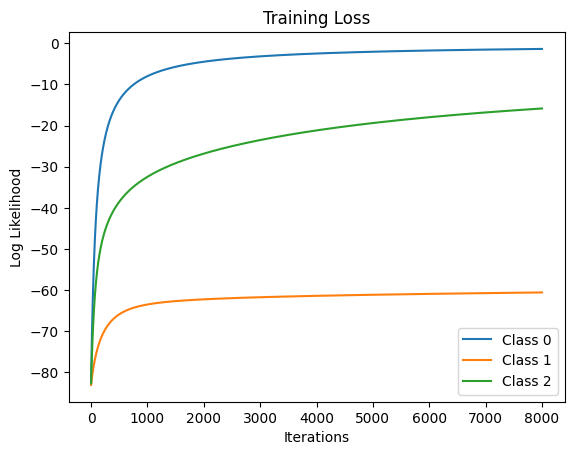

In [12]:
for c in losses_all:
    plt.plot(losses_all[c], label=f"Class {c}")

plt.legend()
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Likelihood")
plt.show()


# **Part 3 — Scikit-learn Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score


Train OvR models

In [14]:
sk_models = {}
feature_names = iris.feature_names

for c in [0,1,2]:
    y_bin = make_binary(y_train, c)

    model = LogisticRegression(penalty=None, max_iter=5000)
    model.fit(X_train, y_bin)

    sk_models[c] = model

    weights = model.coef_[0]

    ranking = sorted(
        zip(feature_names, weights, np.abs(weights)),
        key=lambda x: x[2],
        reverse=True
    )

    print(f"\nClass {c} top 3 features:")
    for r in ranking[:3]:
        print(r)



Class 0 top 3 features:
('petal length (cm)', np.float64(-5.737384277012431), np.float64(5.737384277012431))
('petal width (cm)', np.float64(-4.771109980210399), np.float64(4.771109980210399))
('sepal width (cm)', np.float64(2.863473730130244), np.float64(2.863473730130244))

Class 1 top 3 features:
('petal length (cm)', np.float64(3.6410801490797877), np.float64(3.6410801490797877))
('petal width (cm)', np.float64(-2.8967911682374208), np.float64(2.8967911682374208))
('sepal width (cm)', np.float64(-0.9660073197316329), np.float64(0.9660073197316329))

Class 2 top 3 features:
('petal width (cm)', np.float64(139.37723162509022), np.float64(139.37723162509022))
('petal length (cm)', np.float64(80.55954121202542), np.float64(80.55954121202542))
('sepal width (cm)', np.float64(-21.621219100867823), np.float64(21.621219100867823))


In [22]:
for c in [0,1,2]:
    y_bin = make_binary(y_train, c)
    preds = sk_models[c].predict(X_train)
    acc = accuracy_score(y_bin, preds)
    print(f"Class {c} training accuracy:", acc)


Class 0 training accuracy: 1.0
Class 1 training accuracy: 0.7416666666666667
Class 2 training accuracy: 1.0


Confusion matrix on test set

In [15]:
probs = []

for c in [0,1,2]:
    probs.append(sk_models[c].predict_proba(X_test)[:,1])

probs = np.vstack(probs).T
y_pred = np.argmax(probs, axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  3  7]]


# **Part 4 — L1 Regularization**

In [16]:
l1_models = {}

for c in [0,1,2]:
    y_bin = make_binary(y_train, c)

    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        max_iter=5000
    )

    model.fit(X_train, y_bin)
    l1_models[c] = model


Compare weights

In [20]:
for c in [0,1,2]:
    print("\nClass", c)

    weights_no_reg = sk_models[c].coef_[0]
    weights_l1 = l1_models[c].coef_[0]

    table = []

    for fname, w1, w2 in zip(feature_names,
                              weights_no_reg,
                              weights_l1):

        table.append([
            fname,
            w1,
            abs(w1),
            w2,
            "Yes" if abs(w2) < 1e-6 else "No"
        ])

    df = pd.DataFrame(table,
                      columns=["Feature",
                               "Weight(NoReg)",
                               "|Weight|",
                               "Weight(L1)",
                               "Zeroed?"])

    display(df.sort_values("|Weight|", ascending=False))




Class 0


,Feature,Weight(NoReg),|Weight|,Weight(L1),Zeroed?
2,petal length (cm),-5.737384,5.737384,-1.980590,No
3,petal width (cm),-4.771110,4.771110,0.000000,Yes
1,sepal width (cm),2.863474,2.863474,0.233151,No
0,sepal length (cm),-1.689983,1.689983,0.000000,Yes



Class 1


,Feature,Weight(NoReg),|Weight|,Weight(L1),Zeroed?
2,petal length (cm),3.641080,3.641080,0.000000,Yes
3,petal width (cm),-2.896791,2.896791,0.000000,Yes
1,sepal width (cm),-0.966007,0.966007,-0.532721,No
0,sepal length (cm),-0.672719,0.672719,0.000000,Yes



Class 2


,Feature,Weight(NoReg),|Weight|,Weight(L1),Zeroed?
3,petal width (cm),139.377232,139.377232,1.502288,No
2,petal length (cm),80.559541,80.559541,0.000000,Yes
1,sepal width (cm),-21.621219,21.621219,0.000000,Yes
0,sepal length (cm),-5.405448,5.405448,0.000000,Yes


# **Part 5 — Evaluation**

In [18]:
for name, models_set in [("No Reg", sk_models),
                         ("L1", l1_models)]:

    probs = []
    for c in [0,1,2]:
        probs.append(models_set[c]
                     .predict_proba(X_test)[:,1])

    probs = np.vstack(probs).T
    preds = np.argmax(probs, axis=1)

    print(name, "Accuracy:",
          accuracy_score(y_test, preds))


No Reg Accuracy: 0.9
L1 Accuracy: 0.9333333333333333


Count zero weights

In [19]:
for c in [0,1,2]:
    w = l1_models[c].coef_[0]
    zeros = np.sum(np.abs(w) < 1e-6)
    print(f"Class {c}: zeroed features =", zeros)


Class 0: zeroed features = 2
Class 1: zeroed features = 3
Class 2: zeroed features = 3


In [21]:
results = []

for name, models_set in [("No Reg", sk_models),
                         ("L1", l1_models)]:

    probs = []
    for c in [0,1,2]:
        probs.append(models_set[c]
                     .predict_proba(X_test)[:,1])

    probs = np.vstack(probs).T
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    results.append([name, acc])

pd.DataFrame(results, columns=["Model", "Test Accuracy"])


,Model,Test Accuracy
0,No Reg,0.900000
1,L1,0.933333


Top features across all classes were mainly:
- Petal length
- Petal width

These features consistently appeared among the highest weighted
features in OvR classifiers, showing they are most discriminative.


# **Part 6 — Analysis and Reflection**

### 1. Were the most important features consistent across all three class-vs-rest classifiers?
Yes, **petal length** and **petal width** were consistently among the top features for all three classes.  
These features strongly separate the Iris classes, which aligns with botanical knowledge that petal dimensions are more discriminative than sepal dimensions.



### 2. Did any features appear important for one class but not others?
Yes, **sepal width** had moderate influence for class 0 and 1, but it was less important for class 2.  
This shows that some features are class-specific and contribute differently depending on the OvR classifier.



### 3. How does L1 regularization affect interpretability?
L1 regularization increased interpretability by **zeroing out less important features**, leaving only the most significant ones.  
For example, several features had weights reduced to zero, making it clear which features the model truly relies on.  
This sparsity is especially useful when explaining model predictions or selecting features for downstream tasks.



### 4. If you had to select 5 total features for all classes, which would you pick and why?
Based on consistency and weight magnitude, the following five features are recommended:
1. Petal length  
2. Petal width  
3. Sepal length  
4. Sepal width  
5. (Optional) None or a secondary petal/sepal interaction, depending on domain knowledge  

Petal length and width are essential because they consistently dominate all OvR classifiers.  
Sepal measurements can provide extra discriminative power for class 0 and 1, especially after L1 regularization removed weaker features.



**Summary:**  
The analysis confirms that L1 regularization improves feature selection, highlights the most discriminative features, and helps simplify the model without sacrificing accuracy.  
Overall, petal dimensions are the most important predictors in the Iris dataset, while sepal dimensions provide supporting information for specific classes.


# **Bonus: L1-Regularized Logistic Regression (from scratch)**

Implementation

In [24]:
def train_logistic_l1(X, y, lr=0.0001, iterations=8000, lam=0.1):
    n, d = X.shape

    X_bias = np.c_[np.ones(n), X]  # add bias term
    w = np.zeros(d + 1)

    losses = []

    for _ in range(iterations):
        z = X_bias @ w
        y_hat = sigmoid(z)

        # gradient of log-likelihood
        gradient = X_bias.T @ (y - y_hat)

        # L1 subgradient (exclude bias term)
        subgrad = np.sign(w)
        subgrad[0] = 0  # do not regularize bias

        # gradient ascent with L1
        w += lr * (gradient - lam * subgrad)

        # log-likelihood with L1 penalty for monitoring
        ll = np.sum(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))
        ll -= lam * np.sum(np.abs(w[1:]))  # exclude bias
        losses.append(ll)

    return w, losses


Train OvR models

In [25]:
l1_manual_models = {}
l1_manual_losses = {}

lam = 0.1  # same as sklearn C ~ 1/λ

for c in [0,1,2]:
    y_bin = make_binary(y_train, c)
    w, losses = train_logistic_l1(X_train, y_bin, lr=0.0001, iterations=8000, lam=lam)
    l1_manual_models[c] = w
    l1_manual_losses[c] = losses
    acc = accuracy(X_train, y_bin, w)
    print(f"Class {c} L1 manual training accuracy: {acc:.3f}")


Class 0 L1 manual training accuracy: 1.000
Class 1 L1 manual training accuracy: 0.700
Class 2 L1 manual training accuracy: 0.975


Plot L1 Loss Curves

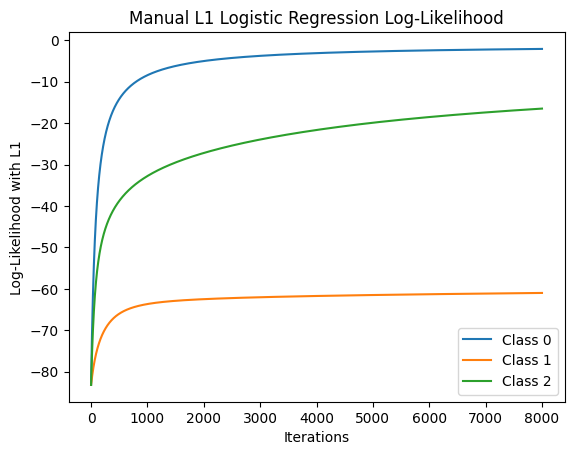

In [26]:
for c in l1_manual_losses:
    plt.plot(l1_manual_losses[c], label=f"Class {c}")

plt.legend()
plt.title("Manual L1 Logistic Regression Log-Likelihood")
plt.xlabel("Iterations")
plt.ylabel("Log-Likelihood with L1")
plt.show()


Compare with scikit-learn L1

In [27]:
for c in [0,1,2]:
    w_manual = l1_manual_models[c]
    w_sklearn = l1_models[c].coef_[0]

    print(f"\nClass {c} comparison:")
    print("Manual weights:", np.round(w_manual[1:], 3))
    print("Sklearn weights:", np.round(w_sklearn, 3))



Class 0 comparison:
Manual weights: [-1.058  1.579 -2.035 -1.883]
Sklearn weights: [ 0.     0.233 -1.981  0.   ]

Class 1 comparison:
Manual weights: [ 0.104 -1.224  0.941 -0.977]
Sklearn weights: [ 0.    -0.533  0.     0.   ]

Class 2 comparison:
Manual weights: [ 0.053 -0.081  1.809  3.302]
Sklearn weights: [0.    0.    0.    1.502]
